 <font size="10">**Notebook 03: Maternal contamination checking: part 2**</font>
***

<div class="alert alert-info">
    
<b> <h1> ℹ️ <strong> <font size="6" color="black"> Important notebook information </font> </strong> </h1> </b>
    <hr>
    <font size="4" color="black">
        The purpose of this notebook is to investigate the chance of there being some maternal cells in the whole embryo scRNAseq data. <br> <br>
    To do this we will use the output from Souporcell running with k = 1 (single genotype - Embryo), k = 2 (two geneotypes, embryo and mother assuming smaller frction is mother) and k = 3 (control)  <br> <br>
    This notebook follows the same logic used in the paper <a href="https://www.science.org/doi/10.1126/science.abo0510">Mapping the developing human immune system across organs</a> however instead of running it per donor as the whole embryo data has sectional information and matenral cells could come from maternal tissue not being removed prior to digestion this notebook is checking each individual lane <br> <br>
    
    Note: this notebook is ran in R (v.4.0.3) not python </font>

***
# Import packages

In [1]:
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Assign paths

In [2]:
path = '/nfs/team298/ar32/Whole_embryo/Maternal_contamination/souporcell_outs/'
donors = c('F137','F147','F158')

# Make dataframe for scoring souporcell models by BIC scoring

In [3]:
df = data.frame(row.names = c('k=1','k=2','k=3','log_prob improvement','BIC_k=1','BIC_k=2','BIC_k=3'))
BIC = data.frame(row.names = c('loci_1','loci_2','loci_3','no_cells'), stringsAsFactors = FALSE)



#all_lanes <- list()

for (donor in donors){
    lanes = list.dirs(path = paste(path,donor,'/data', sep=''),recursive = FALSE, full.names=FALSE)
    #all_lanes = append(all_lanes, lanes)
    
    for (lane in lanes){
        for (i in 1:3){
            k=i
            k_dir = paste(path, donor, '/data/', lane, '/soc', i, '/clusters.err', sep='')
            err = readLines(k_dir)
            log_prob = as.numeric(strsplit(err[length(err)], split='=')[[1]][2])
            df[k,lane] = log_prob
            
            loci_used = as.numeric(strsplit(err[1], split=' ')[[1]][4])
            BIC[k,lane] = loci_used
        }
        
        df[4, lane] = (df[3, lane] - df[2, lane]) / (df[2, lane] - df[1, lane]) # calculate (k=3-k=2)/(k=2-k=1)
        
        # get the number of cells within the lane for BIC scoring
        lane_souporcell_out <- read.csv(paste(path,donor,'/data/', lane,'/soc2/clusters.tsv', sep=''), sep='\t')
        BIC[4, lane] = as.numeric(nrow(lane_souporcell_out))
        
        # BIC scoring
        
        # BIC = -2 * LL + log(N) * k
    
        # LL = log likelihood
        # N is the number of examples in a training dataset
        # k is the number of parameters in the model
        for (i in 1:3){
            k=i
            df[i+4, lane] = -2*df[i,lane] + i*BIC[k,lane]*log(BIC[4, lane])
        }
    }
    
}

In [4]:
# get the model with the smallest BIC score
columns_best_model_1 <- list()
columns_best_model_2 <- list()
columns_best_model_3 <- list()


l <- 1
n_lane = ncol(df)
col_names <- names(df)
for (i in 1:n_lane){
    if (df['BIC_k=1',i] < df['BIC_k=2',i] && df['BIC_k=1',i] < df['BIC_k=3',i]) {
        df['smallest_BIC_model',i] = 'BIC_k=1'
        columns_best_model_1[[l]] <- col_names[l]
        l <- l + 1
        } else if (df['BIC_k=2',i] < df['BIC_k=1',i] && df['BIC_k=2',i] < df['BIC_k=3',i]){
        df['smallest_BIC_model',i] = 'BIC_k=2'
        columns_best_model_2[[l]] <- col_names[l]
        l <- l + 1
        } else {
        df['smallest_BIC_model',i] = 'BIC_k=3'
        columns_best_model_3[[l]] <- col_names[l]
        l <- l + 1
    }  
}

columns_best_model_1<-columns_best_model_1[!sapply(columns_best_model_1,is.null)]
columns_best_model_2<-columns_best_model_2[!sapply(columns_best_model_2,is.null)]
columns_best_model_3<-columns_best_model_3[!sapply(columns_best_model_3,is.null)]

In [5]:
df

,WS_wEMB10202336,WS_wEMB10202337,WS_wEMB10202338,WS_wEMB10202339,WS_wEMB10202340,WS_wEMB10202341,WS_wEMB10202342,WS_wEMB10202343,WS_wEMB10202344,WS_wEMB10202345,⋯,WS_wEMB12142146,WS_wEMB12142147,WS_wEMB12142148,WS_wEMB12142149,WS_wEMB12142150,WS_wEMB12142151,WS_wEMB12142152,WS_wEMB12142153,WS_wEMB12142154,WS_wEMB12142155
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
k=1,-2527867.3,-3758831,-5366971.5,-5159735.5,-3260753,-2778066,-5349067,-3069223.5,-5681241,-3303634.3,⋯,-3199094.8,-4370518,-3508646.3,-4180772.8,-3101943.3,-2179094.8,-684966.06,-3323146.8,-3913455.3,-3342183
k=2,-2465164.8,-3671451.5,-5225835,-5023265,-3179331,-2727959,-5238239,-3006041,-5550368.5,-3242821.5,⋯,-3143969.8,-4305213.5,-3445089.8,-4107395,-3049816.5,-2142095.8,-669974.1,-3258731.8,-3842342.5,-3286483
k=3,-2418349.3,-3616206,-5138020,-4937142.5,-3126140.8,-2692236.3,-5164395,-2963269.8,-5473575,-3200725.5,⋯,-3102864.8,-4253413,-3397030,-4043530.3,-3010865.3,-2113172.3,-658721.1,-3206818.8,-3786461.5,-3243084
log_prob improvement,0.746628922291775,0.632247838451811,0.62219907678028,0.631070451123137,0.653265702144386,0.712928333366599,0.66629371638936,0.67694693942152,0.586781027335766,0.692222689960011,⋯,0.745668934240363,0.793214862681745,0.75617442747791,0.870354521394759,0.747239423866424,0.781737344252547,0.750602322845041,0.805914771404176,0.785807899562388,0.779156193895871
BIC_k=1,5138231.2481682,7849191.98529784,11151839.048069,10723613.7424148,6805363.61834736,5767614.0606868,11018711.5582978,6361873.90393881,11659774.5347642,6820981.37720832,⋯,6723334.86739152,9274017.06120905,7429281.90387397,8902713.2700665,6566666.54066767,4637793.04034972,1458764.40221991,7008500.99512747,8201578.02787985,7066158.61825983
BIC_k=2,5095322.8963364,8005962.97059569,11287462.096138,10854815.4848295,6926377.23669472,5878882.1213736,11117633.1165956,6458935.80787762,11695322.0695284,6913068.55441665,⋯,6938230.13478304,9676389.12241809,7714158.20774794,9297125.340133,6825192.88133534,4843398.48069945,1517612.76443981,7241878.39025494,8434019.8557597,7336551.23651965
BIC_k=3,5084188.5445046,8227001.95589353,11529728.144207,11086713.2272443,7103854.45504209,6018918.78206041,11290522.6748933,6596820.31181642,11839027.6042926,7042589.33162497,⋯,7181165.40217455,10105769.1836271,8030027.91162192,9710563.6101995,7110070.42200301,5065154.92104917,1583939.04665972,7500259.7853824,8696925.28363955,7631545.85477948
smallest_BIC_model,BIC_k=3,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,⋯,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1,BIC_k=1


In [6]:
length(columns_best_model_1)

[1] 135

In [7]:
length(columns_best_model_2)

[1] 3

In [8]:
length(columns_best_model_3)

[1] 1

In [9]:
k2_df <- df[ , names(df) %in% columns_best_model_2]
k2_df

,WS_wEMB10202351,WS_wEMB10202353,WS_wEMB10202356
,<chr>,<chr>,<chr>
k=1,-5078499,-5546365,-3984781.5
k=2,-4944816.5,-5398919,-3853573.5
k=3,-4860056,-5303198,-3776959.3
log_prob improvement,0.634043348979859,0.649193603081806,0.583914090604233
BIC_k=1,10414978.689229,11386518.0581238,8212804.90039792
BIC_k=2,10405594.378458,11385414.1162476,8193630.80079583
BIC_k=3,10494054.067687,11487760.1743714,8283644.30119375
smallest_BIC_model,BIC_k=2,BIC_k=2,BIC_k=2


In [10]:
k2_df <- df[ , names(df) %in% columns_best_model_2]
k2_df

,WS_wEMB10202351,WS_wEMB10202353,WS_wEMB10202356
,<chr>,<chr>,<chr>
k=1,-5078499,-5546365,-3984781.5
k=2,-4944816.5,-5398919,-3853573.5
k=3,-4860056,-5303198,-3776959.3
log_prob improvement,0.634043348979859,0.649193603081806,0.583914090604233
BIC_k=1,10414978.689229,11386518.0581238,8212804.90039792
BIC_k=2,10405594.378458,11385414.1162476,8193630.80079583
BIC_k=3,10494054.067687,11487760.1743714,8283644.30119375
smallest_BIC_model,BIC_k=2,BIC_k=2,BIC_k=2


### WS_wEMB10202351 = Section_05_c F137
### WS_wEMB10202353 = Section_06_a F137
### WS_wEMB10202356 = Section_06_d F137

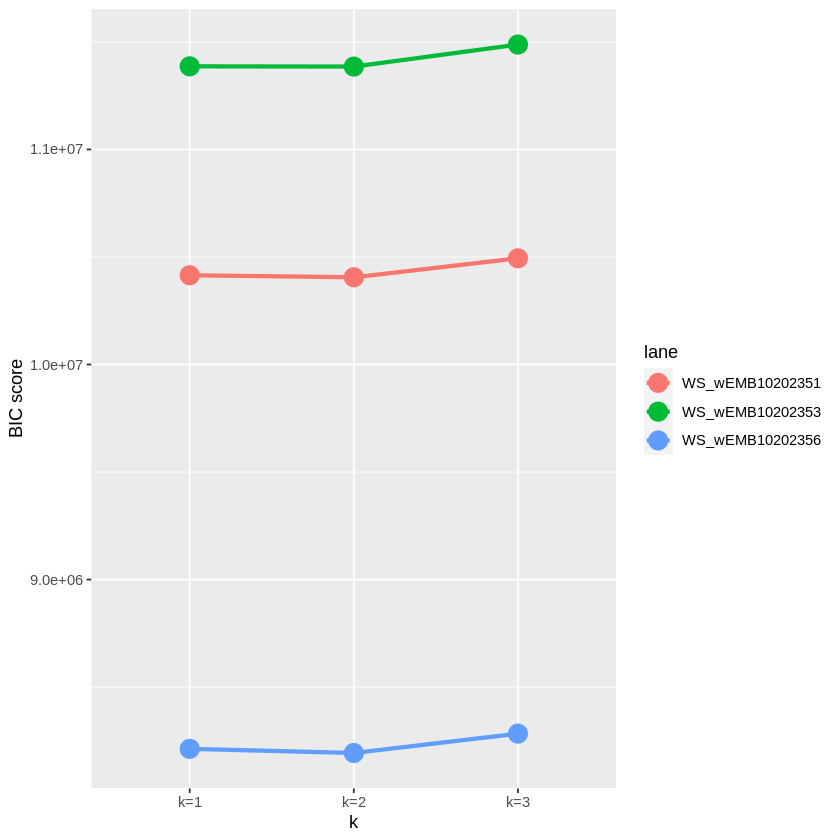

In [11]:
# plot BIC scores
df_selected = df[,df['smallest_BIC_model',]=='BIC_k=2']
n_lane_selected = ncol(df_selected)
df2 = data.frame('metric_name' = c(rep('k=1',n_lane_selected), rep('k=2',n_lane_selected),rep('k=3',n_lane_selected)),
                 'metric' = c(as.numeric(df_selected['BIC_k=1',]), as.numeric(df_selected['BIC_k=2',]),as.numeric(df_selected['BIC_k=3',])),
                 'lane' = rep(colnames(df_selected),3))
ggplot(data = df2, mapping = aes(y = metric, x = metric_name, group = lane, colour=lane)) +
  geom_line(size=1.2) +
  geom_point(size=5) +
  labs(y= "BIC score", x = "k")

### the only lane which had k = 3 was the only lane for Section_01 for embryo 1 (F137) which is known to have minimum cell numbers to begin with. As this lane contains all remaining cells from suspension to maximise cell number capture due to original chip failure it is likely to contain some noise and artefacts which matches the high background seen in the barecode rank plot from CellRanger. As these souporcell model runs were ran on non-filtered cells this is not appropriate for this lane and may need to be ran on only filtered cells to check liklihood later 

## focussing on lanes that scored k = 2 

In [12]:
maternal_barcodes = c()

souporcell_output_donor_list <- list()

donor <- "F137"

for (lane in columns_best_model_2){
    df_m <- read.csv(paste(path,donor,'/data/', lane,'/soc2/clusters.tsv', sep=''), sep='\t')
    df_m$lane <- lane
    souporcell_output_donor_list[[lane]] = df_m
}

souporcell_output_donor <- Reduce(function(x, y) merge(x, y, all=TRUE), souporcell_output_donor_list) 
                                  
souporcell_output_donor <- arrange(souporcell_output_donor,lane)

In [13]:
# number of lanes in the donor
nrow(unique(souporcell_output_donor[c("lane")]))

[1] 3

In [14]:
souporcell_output_donor

barcode,status,assignment,log_prob_singleton,log_prob_doublet,cluster0,cluster1,lane
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAACCTGAGCCAGTTT-1,doublet,0/1,-950.448378,-926.412357,-950.448378,-961.451321,WS_wEMB10202351
AAACCTGAGCCATCGC-1,singlet,1,-895.577987,-898.788448,-920.725607,-895.577987,WS_wEMB10202351
AAACCTGAGGACCACA-1,singlet,1,-15.181128,-15.248309,-15.402513,-15.181128,WS_wEMB10202351
AAACCTGCAATAACGA-1,singlet,0,-801.262765,-806.631893,-801.262765,-830.581248,WS_wEMB10202351
AAACCTGCAATCCAAC-1,singlet,1,-585.344122,-585.662045,-594.629220,-585.344122,WS_wEMB10202351
AAACCTGCACAGAGGT-1,singlet,1,-1536.988455,-1568.283095,-1743.083874,-1536.988455,WS_wEMB10202351
AAACCTGCATAGACTC-1,singlet,1,-418.331426,-427.798457,-438.958059,-418.331426,WS_wEMB10202351
AAACCTGGTAAGAGAG-1,singlet,1,-665.911628,-668.608577,-687.270419,-665.911628,WS_wEMB10202351
AAACCTGGTCCGAGTC-1,singlet,0,-795.458436,-801.680084,-795.458436,-823.047242,WS_wEMB10202351


In [15]:
if (sum(souporcell_output_donor$assignment==0) > sum(souporcell_output_donor$assignment==1)){
    maternal_genotype = 1
  } else {
    maternal_genotype = 0
  }
maternal_barcodes = c(maternal_barcodes, souporcell_output_donor$barcode[souporcell_output_donor$assignment==maternal_genotype])

In [16]:
length(maternal_barcodes)

[1] 8774

In [17]:
nrow(souporcell_output_donor)

[1] 20436

In [18]:
(length(maternal_barcodes) / nrow(souporcell_output_donor)) *100

[1] 42.93404

In [19]:
DF = data.frame(matrix(ncol=5, nrow=0))
colnames(DF) <-c('Lane','Maternal_genotype_cluster','Maternal_cells','Embryo_cells','Maternal_percentage')


row = 1
for (L in unique(souporcell_output_donor[,"lane"])){
    df_sub <- subset(souporcell_output_donor, lane == L)
    if (sum(df_sub$assignment==0) < sum(df_sub$assignment==1)){
        maternal_genotype = 0
    } else {
        maternal_genotype = 1
    }
    
    maternal_cells <- nrow(subset(df_sub, assignment == maternal_genotype))
    
    embryo_cells <- nrow(df_sub) - maternal_cells
    
    maternal_percentage <- ((maternal_cells / nrow(df_sub)) * 100)
    
    DF[row,] = c(L, maternal_genotype, maternal_cells, embryo_cells, maternal_percentage)
    
    row = row + 1
}

DF <- arrange(DF,lane)

In [20]:
DF

Lane,Maternal_genotype_cluster,Maternal_cells,Embryo_cells,Maternal_percentage
<chr>,<chr>,<chr>,<chr>,<chr>
WS_wEMB10202351,1,2760,3803,42.053938747524
WS_wEMB10202353,1,3156,4158,43.1501230516817
WS_wEMB10202356,0,2819,3740,42.9791126696143


In [21]:
sum(as.numeric(DF$Maternal_cells))

[1] 8735

In [22]:
maternal_barcodes_2 = c()

for (L in unique(DF[,"Lane"])){
    df_sub <- subset(souporcell_output_donor, lane == L)
    df_sub$index_barcode <- paste(vapply(strsplit(df_sub$barcode,"-"), `[`, 1, FUN.VALUE=character(1)), df_sub$lane, sep="-")
    DF_sub <- subset(DF, Lane == L)
    
    #df_sub <- subset(df_sub, assignment == as.integer(DF_sub$Maternal_genotype_cluster))
    
    maternal_barcodes_2 = c(maternal_barcodes_2, subset(df_sub, df_sub$assignment==DF_sub$Maternal_genotype_cluster)$index_barcode)
}

In [23]:
length(maternal_barcodes_2)

[1] 8735

In [24]:
nrow(souporcell_output_donor)

[1] 20436

In [25]:
(length(maternal_barcodes_2) / nrow(souporcell_output_donor)) *100

[1] 42.7432

In [26]:
write.csv(maternal_barcodes_2, file = 'maternal_barcodes_20220824.csv')

## for self check of the trouble lane also flag cells for k = 3

In [27]:
maternal_barcodes2 = c()

souporcell_output_donor_list2 <- list()

donor <- "F137"

for (lane in columns_best_model_3){
    df_m <- read.csv(paste(path,donor,'/data/', lane,'/soc2/clusters.tsv', sep=''), sep='\t')
    df_m$lane <- lane
    souporcell_output_donor_list2[[lane]] = df_m
}

souporcell_output_donor2 <- Reduce(function(x, y) merge(x, y, all=TRUE), souporcell_output_donor_list2) 
                                  
souporcell_output_donor2 <- arrange(souporcell_output_donor2,lane)

In [28]:
# number of lanes in the donor
nrow(unique(souporcell_output_donor2[c("lane")]))

[1] 1

In [29]:
souporcell_output_donor2

barcode,status,assignment,log_prob_singleton,log_prob_doublet,cluster0,cluster1,lane
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAACCTGAGATCCGAG-1,singlet,1,-1348.35025,-1361.73986,-1416.43754,-1348.35025,WS_wEMB10202336
AAACCTGAGTACGATA-1,singlet,1,-1151.68518,-1171.34778,-1222.13224,-1151.68518,WS_wEMB10202336
AAACCTGCAGGTCCAC-1,singlet,1,-1094.81858,-1106.03547,-1164.99549,-1094.81858,WS_wEMB10202336
AAACCTGGTACCTACA-1,singlet,0,-993.79040,-1002.53890,-993.79040,-1034.97882,WS_wEMB10202336
AAACCTGGTATTCTCT-1,unassigned,0,-13.77449,-13.79194,-13.77449,-13.89284,WS_wEMB10202336
AAACCTGTCGCCAGCA-1,singlet,1,-1557.75827,-1576.89245,-1615.44487,-1557.75827,WS_wEMB10202336
AAACGGGAGCCACGTC-1,singlet,0,-434.35203,-439.49842,-434.35203,-485.35448,WS_wEMB10202336
AAACGGGAGCGCCTCA-1,singlet,1,-629.14361,-629.24290,-642.58612,-629.14361,WS_wEMB10202336
AAACGGGAGCGTCAAG-1,singlet,0,-387.84481,-395.84557,-387.84481,-416.87682,WS_wEMB10202336


In [30]:
if (sum(souporcell_output_donor2$assignment==0) > sum(souporcell_output_donor2$assignment==1)){
    maternal_genotype = 1
  } else {
    maternal_genotype = 0
  }
maternal_barcodes2 = c(maternal_barcodes2, souporcell_output_donor2$barcode[souporcell_output_donor2$assignment==maternal_genotype])

In [31]:
length(maternal_barcodes2)

[1] 844

In [32]:
nrow(souporcell_output_donor2)

[1] 2068

In [33]:
(length(maternal_barcodes2) / nrow(souporcell_output_donor2)) *100

[1] 40.81238

In [34]:
DF2 = data.frame(matrix(ncol=5, nrow=0))
colnames(DF2) <-c('Lane','Maternal_genotype_cluster','Maternal_cells','Embryo_cells','Maternal_percentage')


row = 1
for (L in unique(souporcell_output_donor2[,"lane"])){
    df_sub <- subset(souporcell_output_donor2, lane == L)
    if (sum(df_sub$assignment==0) < sum(df_sub$assignment==1)){
        maternal_genotype = 0
    } else {
        maternal_genotype = 1
    }
    
    maternal_cells <- nrow(subset(df_sub, assignment == maternal_genotype))
    
    embryo_cells <- nrow(df_sub) - maternal_cells
    
    maternal_percentage <- ((maternal_cells / nrow(df_sub)) * 100)
    
    DF2[row,] = c(L, maternal_genotype, maternal_cells, embryo_cells, maternal_percentage)
    
    row = row + 1
}

DF2 <- arrange(DF2,lane)

In [35]:
DF2

Lane,Maternal_genotype_cluster,Maternal_cells,Embryo_cells,Maternal_percentage
<chr>,<chr>,<chr>,<chr>,<chr>
WS_wEMB10202336,1,844,1224,40.8123791102514


In [36]:
sum(as.numeric(DF2$Maternal_cells))

[1] 844

In [37]:
maternal_barcodes_2_2 = c()

for (L in unique(DF2[,"Lane"])){
    df_sub <- subset(souporcell_output_donor2, lane == L)
    df_sub$index_barcode <- paste(vapply(strsplit(df_sub$barcode,"-"), `[`, 1, FUN.VALUE=character(1)), df_sub$lane, sep="-")
    DF_sub <- subset(DF2, Lane == L)
    
    #df_sub <- subset(df_sub, assignment == as.integer(DF_sub$Maternal_genotype_cluster))
    
    maternal_barcodes_2_2 = c(maternal_barcodes_2_2, subset(df_sub, df_sub$assignment==DF_sub$Maternal_genotype_cluster)$index_barcode)
}

In [38]:
length(maternal_barcodes_2_2)

[1] 844

In [39]:
nrow(souporcell_output_donor2)

[1] 2068

In [40]:
(length(maternal_barcodes_2_2) / nrow(souporcell_output_donor2)) *100

[1] 40.81238

In [41]:
write.csv(maternal_barcodes_2_2, file = 'maternal_barcodes_trouble_lane_20220829.csv')

# Lanes with best model for K barcodes saved to excel to map to main data and investigate celltypes to evaluate what the cells are and liklihood of the calling being correct.
# Even for models where k = 2 is best by BIC scoring (smallest BIC value), all of these models it is very close to k = 1 as well so if celltypes highlighted as potentially maternal are tissue specific / non-circulating then raise doubt on how well this technique has performed however currently there has not been an established best practise and other alternative for determing maternal cells and as donor mothers are kept annonymous can't do direct comparison with mothers
# Even though souporcell can also be used for doublet detection, doublets are instead flagged in notebook 04_Metadata_addition using the package scrublet

***
### Dependencies
Here are some information about resources and import package versions used within this script

In [42]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 20.04.1 LTS

Matrix products: default
BLAS/LAPACK: /home/jovyan/my-conda-envs/R_4_0_3_env/lib/libopenblasp-r0.3.12.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] fansi_0.5.0       digest_0.6.29     utf8_1.2.2        crayon_1.4.2     
 [5] IRdisplay_1.0     repr_1.1.3        lifecycle_1.0.1   jsonlite_1.7.2   
 [9] evaluate_0.14     pillar_1.6.4      rlang_0.4.12      uuid_0.1-4       
[13] vctrs_0.3.8       ellipsis_0.3.2    IRkernel_1.